<a href="https://colab.research.google.com/github/yigitavseren/DeepVision-SSD/blob/master/DeepVision_SSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont


model_url = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
detector = hub.load(model_url)

print("Model başarıyla yüklendi!")

Model başarıyla yüklendi!


In [18]:
from PIL import Image

def resmi_hazirla(resim_yolu):

    img = Image.open(resim_yolu).convert('RGB')

    img_array = np.array(img)

    input_tensor = tf.convert_to_tensor(img_array)
    return input_tensor[tf.newaxis, ...]

print("Yeni hazırlama fonksiyonu aktif")

Yeni hazırlama fonksiyonu aktif


In [22]:
resim_yolu = 'leadimagetest.jpg'
input_tensor = resmi_hazirla(resim_yolu)
detector_output = detector(input_tensor)
print(" Model resmi işledi.")

 Model resmi işledi.


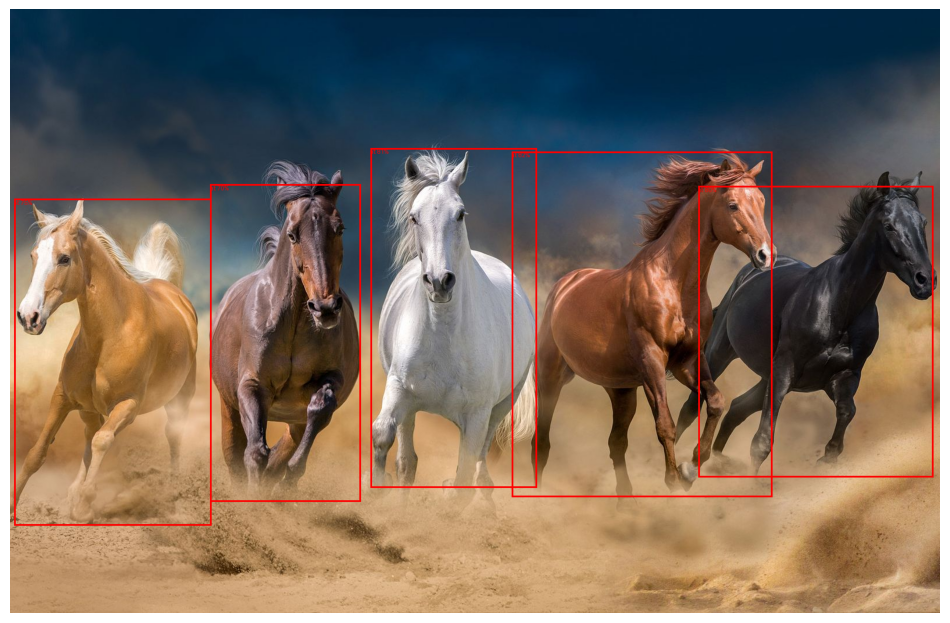

In [23]:

COCO_LABELS = {
    1: 'insan', 2: 'bisiklet', 3: 'araba', 4: 'motosiklet', 6: 'otobüs', 8: 'kamyon',
    10: 'trafik lambası', 13: 'dur tabelası', 17: 'kedi', 18: 'köpek', 19: 'at',
    44: 'şişe', 47: 'fincan', 62: 'sandalye', 64: 'saksı bitkisi', 72: 'televizyon', 77: 'cep telefonu'
}

def kutulari_ciz(resim_yolu, sonuc):
    img = Image.open(resim_yolu).convert('RGB')
    draw = ImageDraw.Draw(img)


    boxes = sonuc['detection_boxes'][0].numpy()
    classes = sonuc['detection_classes'][0].numpy().astype(int)
    scores = sonuc['detection_scores'][0].numpy()

    genislik, yukseklik = img.size

    for i in range(len(scores)):
        if scores[i] > 0.5:

            ymin, xmin, ymax, xmax = boxes[i]
            sol, ust, sag, alt = (xmin * genislik, ymin * yukseklik, xmax * genislik, ymax * yukseklik)


            draw.rectangle([sol, ust, sag, alt], outline="red", width=3)


            label = COCO_LABELS.get(classes[i], f"Nesne ID: {classes[i]}")
            draw.text((sol, ust), f"{label}: {int(scores[i]*100)}%", fill="red")

    return img

sonuc_resmi = kutulari_ciz(resim_yolu, detector_output)
plt.figure(figsize=(12, 8))
plt.imshow(sonuc_resmi)
plt.axis('off')
plt.show()